# Nanoplasma reduced archive exporter + plotting

This notebook:
1. Loads a PIConGPU nanoplasma run via `NanoPlasmaRun` (from `nanoplasma_ana.py`)
2. Exports a compact HDF5 archive (`*_reduced.h5`) with derived diagnostics
3. Re-plots the key figures **from the HDF5 only** (so you can delete raw openPMD safely)

> Adjust paths/species names as needed.


In [4]:
import numpy as np
import h5py
import adios2
import glob
import scipy.constants as sc
from nanoplasma_analysis_final import extract_step_from_filename

SIMOUTPUT = "/p/scratch/jureap18/medina2/2026_nanoplasma/004_Neutral_Smallsteps/simOutput"
OUT_H5    = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run007_reduced.h5"

ION_SPECIES = "He_i"
E_SPECIES   = "He_e"

files = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))

# ---- load grid meta from first file ----
run._load_meta()
dx, dy, dz = float(run.Dx_SI), float(run.Dy_SI), float(run.Dz_SI)

# get grid shape
with adios2.Stream(files[0], "r") as f:
    step0 = extract_step_from_filename(files[0])
    for _ in f.steps():
        Nz, Ny, Nx = np.array(
            f.available_variables()[f"/data/{step0}/fields/B/x"]["Shape"].split(", "),
            dtype=int
        )
        break

print("Grid:", Nx, Ny, Nz)

# ---- open H5 and append slices ----
with h5py.File(OUT_H5, "a") as h5:
    gs = h5.require_group("slices")
    gs.attrs["Nx"] = Nx
    gs.attrs["Ny"] = Ny
    gs.attrs["Nz"] = Nz

    for fn in files:
        step = extract_step_from_filename(fn)
        print("Processing step", step)

        with adios2.Stream(fn, "r") as f:
            for _ in f.steps():
                # --- FIELD |E| ---
                try:
                    Ex = f.read(f"/data/{step}/fields/E/x")
                    Ey = f.read(f"/data/{step}/fields/E/y")
                    Ez = f.read(f"/data/{step}/fields/E/z")
                    Eabs = np.sqrt(Ex*Ex + Ey*Ey + Ez*Ez)
                except Exception:
                    Eabs = None

                # --- PARTICLES ---
                def read_part(sp):
                    x = f.read(f"/data/{step}/particles/{sp}/position/x")
                    y = f.read(f"/data/{step}/particles/{sp}/position/y")
                    z = f.read(f"/data/{step}/particles/{sp}/position/z")
                    xo = f.read(f"/data/{step}/particles/{sp}/positionOffset/x")
                    yo = f.read(f"/data/{step}/particles/{sp}/positionOffset/y")
                    zo = f.read(f"/data/{step}/particles/{sp}/positionOffset/z")
                    w  = f.read(f"/data/{step}/particles/{sp}/weighting")
                    xc = xo + x
                    yc = yo + y
                    zc = zo + z
                    return xc, yc, zc, w

                xi, yi, zi, wi = read_part(ION)
                xe, ye, ze, we = read_part(ELE)

                # center via ion COM
                W = np.sum(wi) + 1e-30
                x0 = np.sum(xi*wi)/W
                y0 = np.sum(yi*wi)/W
                z0 = np.sum(zi*wi)/W

                ix0 = int(np.clip(np.floor(x0), 0, Nx-1))
                iy0 = int(np.clip(np.floor(y0), 0, Ny-1))
                iz0 = int(np.clip(np.floor(z0), 0, Nz-1))

                gstep = gs.require_group(f"step_{step:08d}")
                gstep.attrs["center_cell"] = [x0,y0,z0]

                # ---- FIELD SLICES ----
                if Eabs is not None:
                    gstep.create_dataset("Eabs_xy", data=Eabs[iz0,:,:].astype(np.float32), compression="gzip")
                    gstep.create_dataset("Eabs_xz", data=Eabs[:,iy0,:].astype(np.float32), compression="gzip")
                    gstep.create_dataset("Eabs_yz", data=Eabs[:,:,ix0].astype(np.float32), compression="gzip")

                # ---- PARTICLE MAPS (full grid resolution) ----
                def hist2d_full(xc, yc, w, nx, ny):
                    H, _, _ = np.histogram2d(xc, yc, bins=[nx, ny], weights=w)
                    return H

                ni_xy = hist2d_full(xi, yi, wi, Nx, Ny)
                ne_xy = hist2d_full(xe, ye, we, Nx, Ny)

                gstep.create_dataset("ni_xy", data=ni_xy.astype(np.float32), compression="gzip")
                gstep.create_dataset("ne_xy", data=ne_xy.astype(np.float32), compression="gzip")

                break

print("Slices appended to:", OUT_H5)

NameError: name 'run' is not defined

In [5]:
import os
import numpy as np
import h5py

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# If nanoplasma_ana.py is in the same folder, this will work directly:
from ana_extract import NanoPlasmaRun


In [10]:
# --- User settings ---
SIMOUTPUT = "/p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput/"
LASER_PEAK_STEP = 89603

ION_SPECIES = "He_i"
E_SPECIES   = "He_e"
ZMAX = 2

OUT_H5 = "/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5"

# Physics metadata you want embedded
R0_NM = 20.0
N_HE_M3 = 2.18e28

# Binning (choose generously to stay future-proof)
R_MAX_NM = 2000.0
N_R = 600
MU_BINS = 360
E_MAX_EV = 2000.0
N_E = 800
LOG_E = True


In [11]:
run = NanoPlasmaRun(path=SIMOUTPUT, laser_peak_at_target=LASER_PEAK_STEP)

run.export_reduced_h5(
    out_h5=OUT_H5,
    ion_species=ION_SPECIES,
    e_species=E_SPECIES,
    Zmax=ZMAX,
    r_max_nm=300.0,
    n_r=1200,
    mu_bins=720,
    E_max_eV=2000.0,
    n_E=1200,
    log_energy=True,
    center_mode="each_com",
    store_slices=True,
    overwrite=True,
    verbose=True
)

[export_reduced_h5] outputs: 21
[export_reduced_h5] r bins: 1200 up to 300.0 nm
[export_reduced_h5] mu bins: 720, energy bins: 1200 up to 2000.0 eV
[export_reduced_h5] slices: on (2 stored)
[export_reduced_h5] wrote: /p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5 (0.8 MB)


'/p/scratch/jureap18/medina2/2026_nanoplasma/Run001_reduced.h5'

In [12]:
# --- Load reduced HDF5 ---
h5 = h5py.File(OUT_H5, "r")

t_fs = h5["axes/time_fs"][:]
r_mid_m = h5["axes/r_mid_m"][:]
r_nm = r_mid_m * 1e9

E_mid = h5["axes/E_mid_eV"][:]
mu_mid = h5["axes/mu_mid"][:]

# convenience
ts = h5["timeseries"]
spec = h5["spectra"]
rad = h5["radial"]

print("Nt =", len(t_fs))


Nt = 21


## Plot 1: Ionization fractions + energies (paper panel backbone)

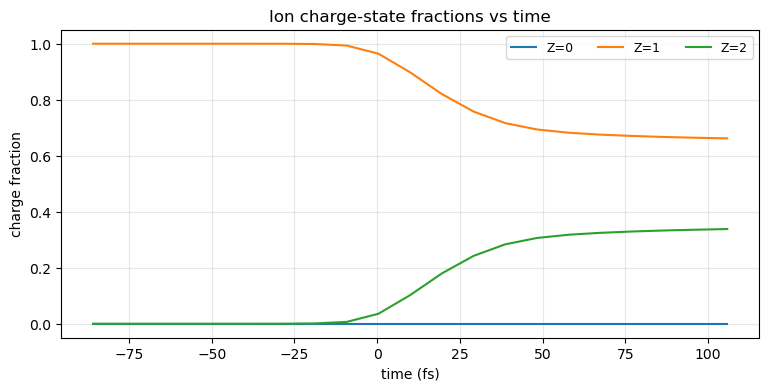

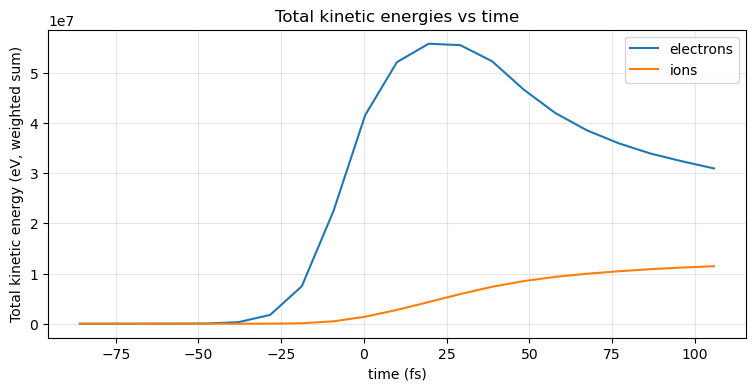

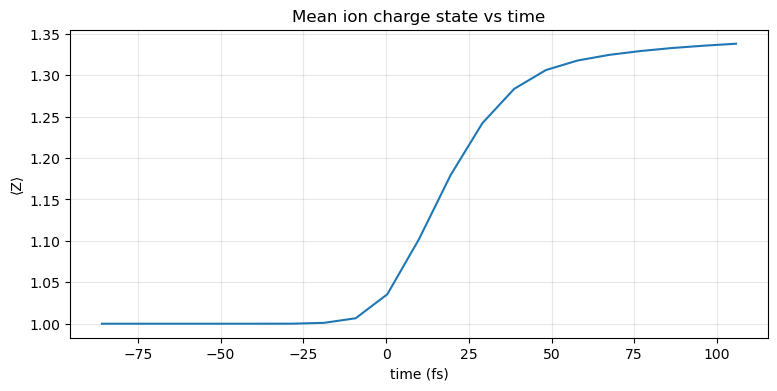

In [13]:
# Ion charge fractions vs time
charge_frac = ts[f"{ION_SPECIES}_charge_frac"][:]     # (Nt, Zmax+1)
Z_mean = ts[f"{ION_SPECIES}_Z_mean"][:]               # (Nt,)

# Energies vs time
Ekin_e = ts[f"{E_SPECIES}_Ekin_total_eV"][:]
Ekin_i = ts[f"{ION_SPECIES}_Ekin_total_eV"][:]

fig, ax = plt.subplots(figsize=(9,4))
for Z in range(charge_frac.shape[1]):
    ax.plot(t_fs, charge_frac[:,Z], label=f"Z={Z}")
ax.set_xlabel("time (fs)")
ax.set_ylabel("charge fraction")
ax.set_title("Ion charge-state fractions vs time")
ax.legend(ncol=3, fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, Ekin_e, label="electrons")
ax.plot(t_fs, Ekin_i, label="ions")
ax.set_xlabel("time (fs)")
ax.set_ylabel("Total kinetic energy (eV, weighted sum)")
ax.set_title("Total kinetic energies vs time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, Z_mean)
ax.set_xlabel("time (fs)")
ax.set_ylabel("⟨Z⟩")
ax.set_title("Mean ion charge state vs time")
ax.grid(True, alpha=0.3)
plt.show()


## Plot 2: Electron energy spectra (time-resolved heatmap + selected times)

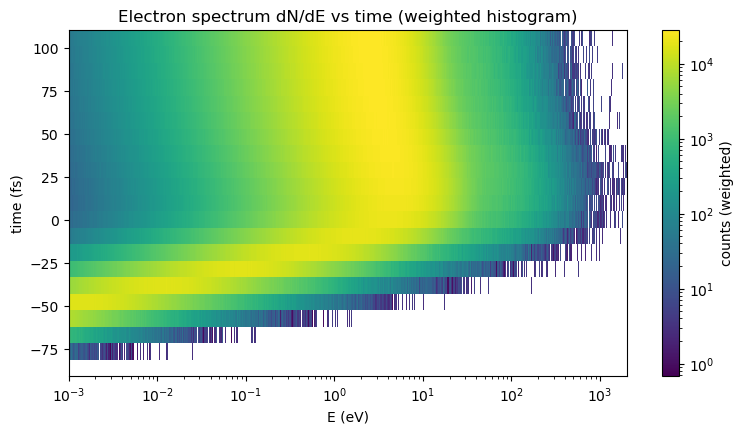

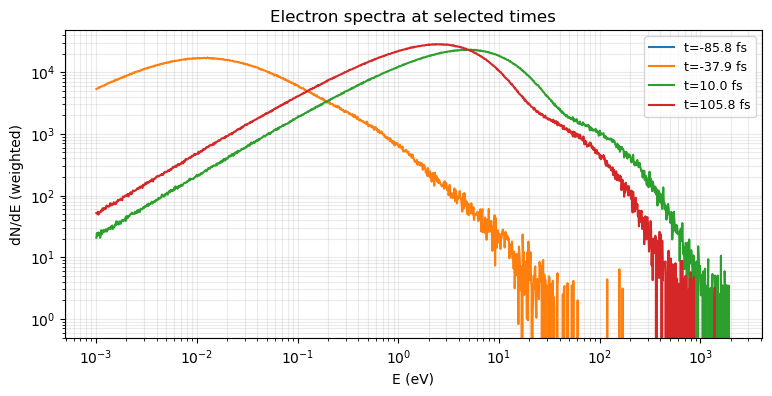

In [14]:
dNdE_e = spec[f"{E_SPECIES}_dNdE"][:]   # (Nt, NE)

# heatmap (log scale)
fig, ax = plt.subplots(figsize=(9,4.5))
# Avoid zeros for LogNorm
H = np.where(dNdE_e>0, dNdE_e, np.nan)
im = ax.pcolormesh(E_mid, t_fs, H, norm=LogNorm(), shading="auto")
ax.set_xscale("log" if LOG_E else "linear")
ax.set_xlabel("E (eV)")
ax.set_ylabel("time (fs)")
ax.set_title("Electron spectrum dN/dE vs time (weighted histogram)")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

# selected time slices
sel = [0, len(t_fs)//4, len(t_fs)//2, -1]
fig, ax = plt.subplots(figsize=(9,4))
for idx in sel:
    ax.plot(E_mid, dNdE_e[idx], label=f"t={t_fs[idx]:.1f} fs")
ax.set_xscale("log" if LOG_E else "linear")
ax.set_yscale("log")
ax.set_xlabel("E (eV)")
ax.set_ylabel("dN/dE (weighted)")
ax.set_title("Electron spectra at selected times")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.25)
plt.show()


## Plot 3: Angular distribution vs time + asymmetry metrics

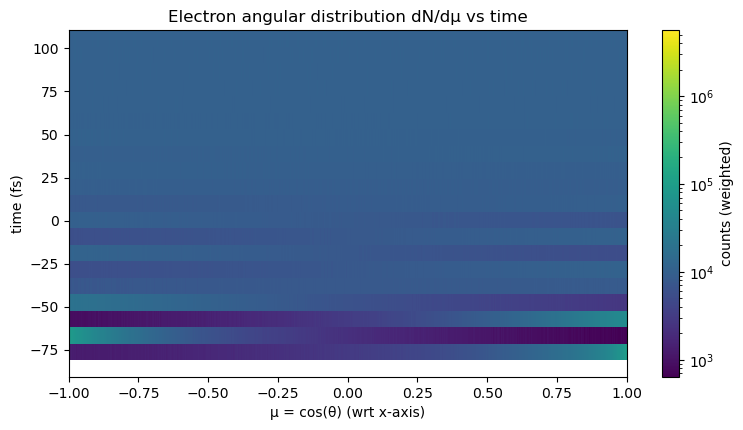

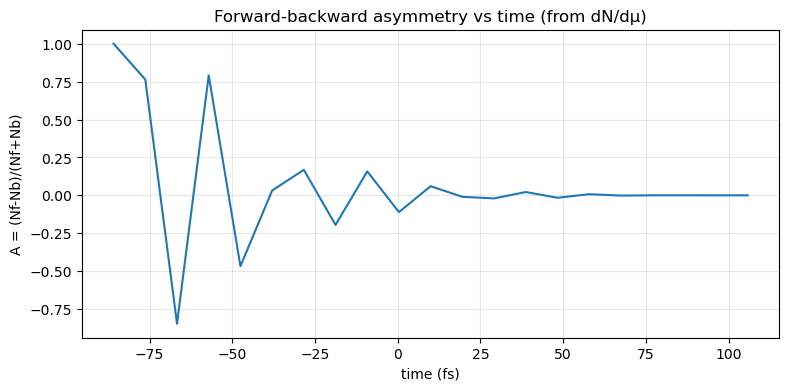

In [15]:
dNdmu = spec[f"{E_SPECIES}_dNdmu"][:]  # (Nt, Nmu)

fig, ax = plt.subplots(figsize=(9,4.5))
H = np.where(dNdmu>0, dNdmu, np.nan)
im = ax.pcolormesh(mu_mid, t_fs, H, norm=LogNorm(), shading="auto")
ax.set_xlabel("μ = cos(θ) (wrt x-axis)")
ax.set_ylabel("time (fs)")
ax.set_title("Electron angular distribution dN/dμ vs time")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

# Simple forward-backward asymmetry A = (N_f - N_b)/(N_f + N_b)
mu = mu_mid
forward = mu > 0
backward = mu < 0
Nf = np.nansum(dNdmu[:, forward], axis=1)
Nb = np.nansum(dNdmu[:, backward], axis=1)
A = (Nf - Nb) / (Nf + Nb + 1e-30)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t_fs, A)
ax.set_xlabel("time (fs)")
ax.set_ylabel("A = (Nf-Nb)/(Nf+Nb)")
ax.set_title("Forward-backward asymmetry vs time (from dN/dμ)")
ax.grid(True, alpha=0.3)
plt.show()


## Plot 4: Radial kymographs + expansion radii

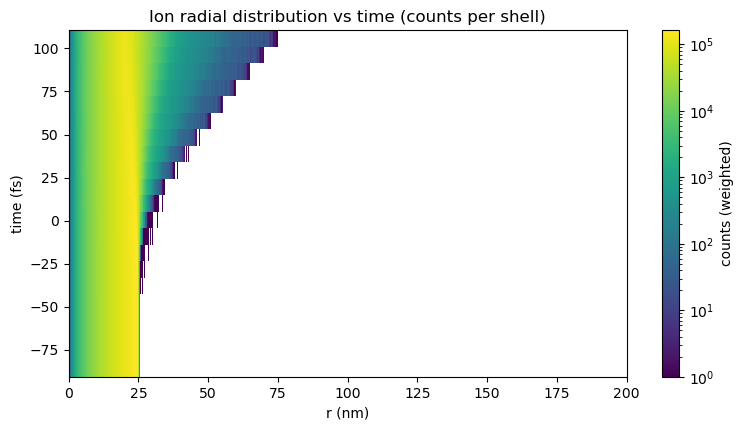

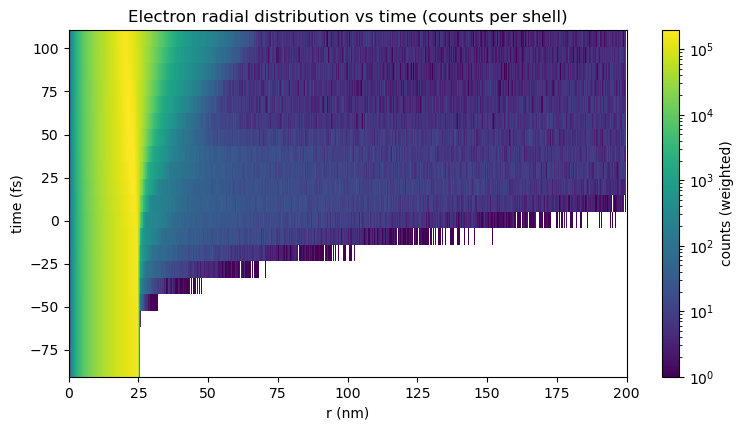

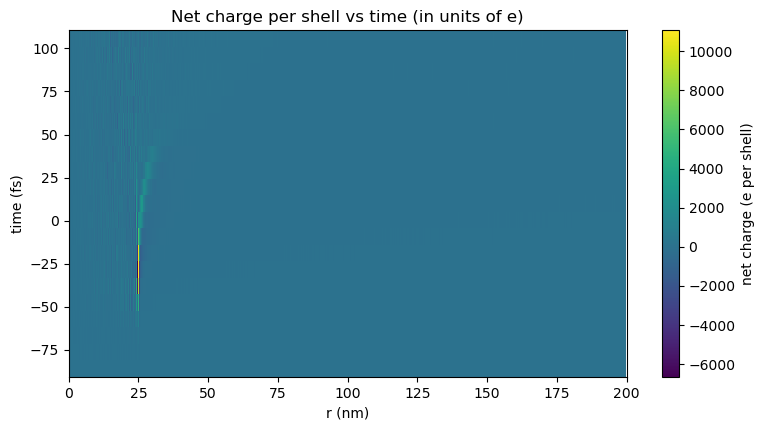

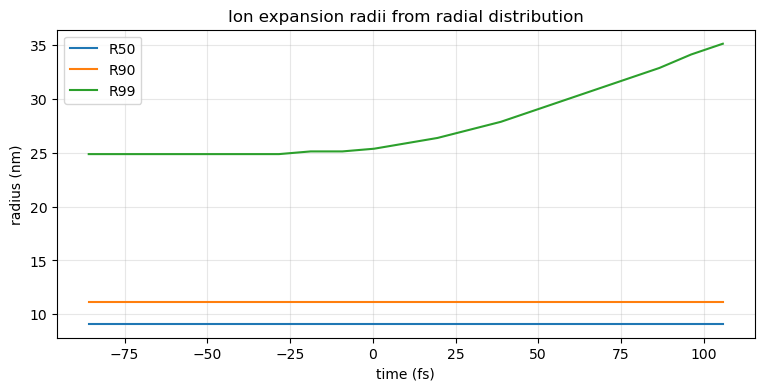

In [12]:
# --- Plot 4 (FIXED AGAIN): Radial kymographs + expansion radii ---

import scipy.constants as sc
from matplotlib.colors import LogNorm

# Axes
r_edges_nm = h5["axes/r_edges_m"][:] * 1e9     # (Nr+1,)
r_mid_nm   = h5["axes/r_mid_m"][:] * 1e9       # (Nr,)
t = t_fs                                       # (Nt,)

# Build time edges for pcolormesh (Nt+1)
dt = np.median(np.diff(t)) if len(t) > 1 else 1.0
t_edges = np.concatenate(([t[0] - 0.5*dt], 0.5*(t[1:] + t[:-1]), [t[-1] + 0.5*dt]))

# Data
n_i = rad[f"{ION_SPECIES}_n_r"][:]              # (Nt, Nr)
n_e = rad[f"{E_SPECIES}_n_r"][:]                # (Nt, Nr)
rho_net_shell_C = rad["rho_net_shell_C"][:]     # (Nt, Nr)

# Choose zoom
R_VIEW_NM = 200  # adjust
# pick number of radial bins to include (ncols)
ncols = int(np.searchsorted(r_edges_nm, R_VIEW_NM, side="right")) - 1
ncols = max(1, min(ncols, n_i.shape[1]))  # clamp

# Ion kymograph
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.pcolormesh(
    r_edges_nm[:ncols+1], t_edges, n_i[:, :ncols],
    norm=LogNorm(vmin=1, vmax=np.nanmax(n_i)),
    shading="flat"
)
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)")
ax.set_ylabel("time (fs)")
ax.set_title("Ion radial distribution vs time (counts per shell)")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

# Electron kymograph
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.pcolormesh(
    r_edges_nm[:ncols+1], t_edges, n_e[:, :ncols],
    norm=LogNorm(vmin=1, vmax=np.nanmax(n_e)),
    shading="flat"
)
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)")
ax.set_ylabel("time (fs)")
ax.set_title("Electron radial distribution vs time (counts per shell)")
fig.colorbar(im, ax=ax, label="counts (weighted)")
plt.show()

# Net charge per shell in units of e (signed)
net_charge_e = rho_net_shell_C / sc.e

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.pcolormesh(
    r_edges_nm[:ncols+1], t_edges, net_charge_e[:, :ncols],
    shading="flat"
)
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)")
ax.set_ylabel("time (fs)")
ax.set_title("Net charge per shell vs time (in units of e)")
fig.colorbar(im, ax=ax, label="net charge (e per shell)")
plt.show()

# Expansion radii (percentiles)
cum = np.cumsum(n_i, axis=1)
tot = cum[:, -1] + 1e-30
cdf = cum / tot[:, None]

def percentile_radius_nm(p):
    idx = np.argmax(cdf >= p, axis=1)
    idx = np.clip(idx, 0, len(r_mid_nm)-1)
    return r_mid_nm[idx]

R50 = percentile_radius_nm(0.05)
R90 = percentile_radius_nm(0.09)
R99 = percentile_radius_nm(0.99)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, R50, label="R50")
ax.plot(t, R90, label="R90")
ax.plot(t, R99, label="R99")
ax.set_xlabel("time (fs)")
ax.set_ylabel("radius (nm)")
ax.set_title("Ion expansion radii from radial distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Plot 5: Charge-state vs radius heatmap (your requested diagnostic)

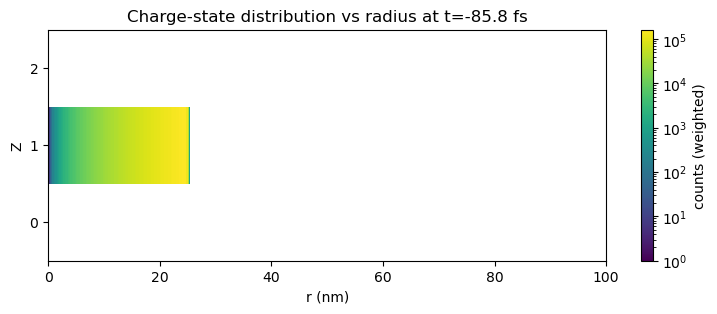

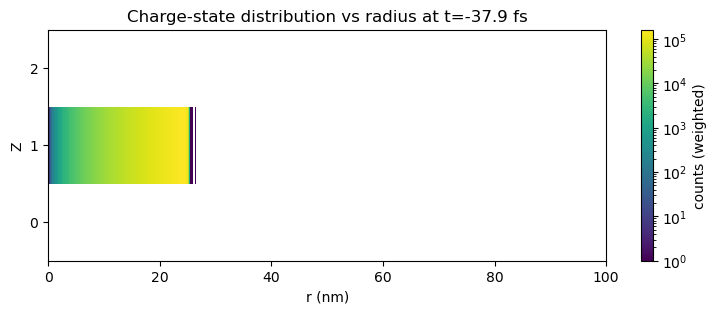

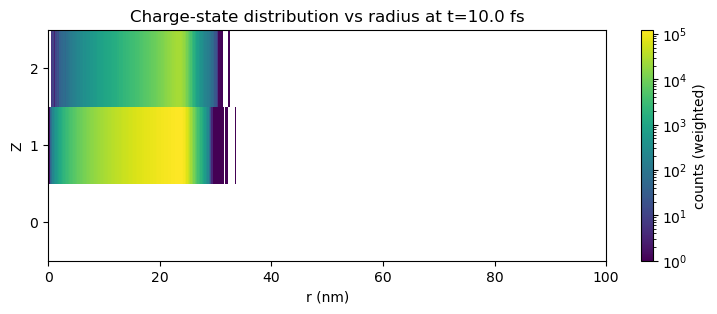

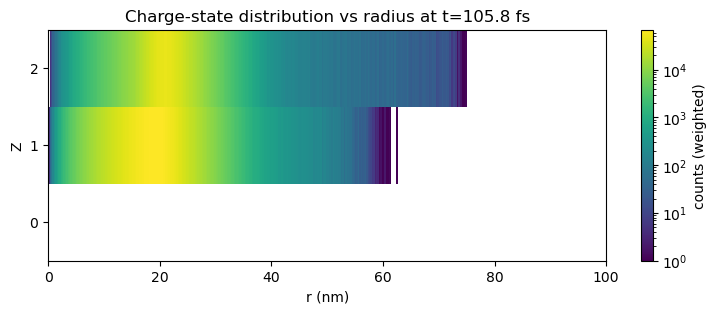

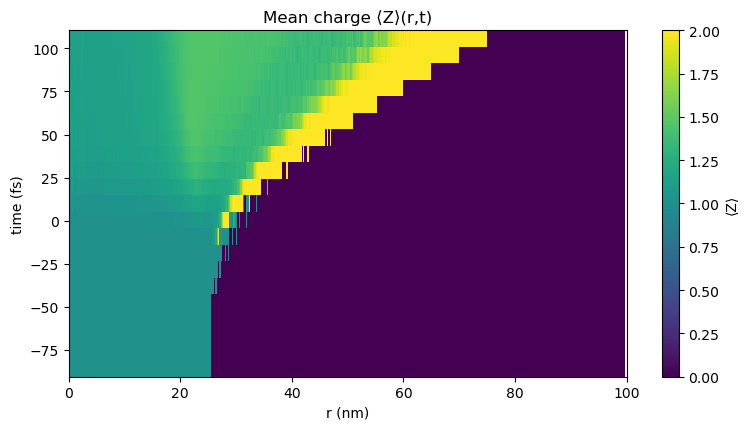

In [14]:
# --- Plot 5 (FIXED AGAIN): Charge-state vs radius heatmap ---

from matplotlib.colors import LogNorm
r_edges_nm = h5["axes/r_edges_m"][:] * 1e9
t = t_fs

# Time edges
dt = np.median(np.diff(t)) if len(t) > 1 else 1.0
t_edges = np.concatenate(([t[0] - 0.5*dt], 0.5*(t[1:] + t[:-1]), [t[-1] + 0.5*dt]))

charge_rZ = rad[f"{ION_SPECIES}_charge_rZ_counts"][:]  # (Nt, Nr, Zmax+1)
Z_values = rad["Z_values"][:]                          # (Zmax+1,)
Zmax = int(Z_values.max())

# Z edges for pcolormesh
Z_edges = np.arange(-0.5, Zmax + 1.5, 1.0)            # length Zmax+2

# Zoom
R_VIEW_NM = 100
ncols = int(np.searchsorted(r_edges_nm, R_VIEW_NM, side="right")) - 1
ncols = max(1, min(ncols, charge_rZ.shape[1]))

# Plot a few times: heatmap Z vs r
sel = [0, len(t)//4, len(t)//2, len(t)-1]
for idx in sel:
    H = charge_rZ[idx, :ncols, :].T  # (Z, r)

    vmax = np.nanmax(H)
    if vmax <= 0:
        print(f"t={t[idx]:.1f} fs: all zeros in plotted window.")
        continue

    fig, ax = plt.subplots(figsize=(9, 3))
    im = ax.pcolormesh(
        r_edges_nm[:ncols+1], Z_edges, H,
        norm=LogNorm(vmin=1, vmax=vmax),
        shading="flat"
    )
    ax.set_xlim(0, R_VIEW_NM)
    ax.set_xlabel("r (nm)")
    ax.set_ylabel("Z")
    ax.set_yticks(Z_values)
    ax.set_title(f"Charge-state distribution vs radius at t={t[idx]:.1f} fs")
    fig.colorbar(im, ax=ax, label="counts (weighted)")
    plt.show()

# Mean charge <Z>(r,t)
num = np.tensordot(charge_rZ, Z_values, axes=([2], [0]))  # (Nt, Nr)
den = np.sum(charge_rZ, axis=2) + 1e-30
Zmean_rt = num / den

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.pcolormesh(
    r_edges_nm[:ncols+1], t_edges, Zmean_rt[:, :ncols],
    shading="flat"
)
ax.set_xlim(0, R_VIEW_NM)
ax.set_xlabel("r (nm)")
ax.set_ylabel("time (fs)")
ax.set_title("Mean charge ⟨Z⟩(r,t)")
fig.colorbar(im, ax=ax, label="⟨Z⟩")
plt.show()

In [22]:
n_i = rad[f"{ION_SPECIES}_n_r"][:]
r_edges_nm = h5["axes/r_edges_m"][:] * 1e9

# where is the distribution (pick a late time)
idx = -1
h = n_i[idx]
peak_bin = np.argmax(h)
print("peak bin r range [nm]:", r_edges_nm[peak_bin], "to", r_edges_nm[peak_bin+1])
print("99% radius approx [nm]:", r_edges_nm[np.searchsorted(np.cumsum(h)/np.sum(h), 0.99)])

peak bin r range [nm]: 0.0 to 3.333333333333334
99% radius approx [nm]: 0.0


In [27]:
import glob
import adios2
import numpy as np
from nanoplasma_analysis_final import extract_step_from_filename

# Path to your openPMD files
path = "/p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput/"

# Collect bp5 files
files = sorted(glob.glob(path + "/openPMD/*.bp5"))
print("Number of files:", len(files))

# Use last timestep (or change index)
fn = files[-1]
print("Testing file:", fn)

ION = ION_SPECIES  # e.g. "He_i"

step = extract_step_from_filename(fn)
print("Step:", step)

with adios2.Stream(fn, "r") as f:
    for _ in f.steps():
        # position
        x = f.read(f"/data/{step}/particles/{ION}/position/x")
        print("position/x:")
        print("   min =", float(np.min(x)))
        print("   max =", float(np.max(x)))
        print("   dtype =", x.dtype)

        # try positionOffset
        try:
            xo = f.read(f"/data/{step}/particles/{ION}/positionOffset/x")
            print("\npositionOffset/x:")
            print("   min =", int(np.min(xo)))
            print("   max =", int(np.max(xo)))
            print("   dtype =", xo.dtype)
        except Exception:
            print("\nNo positionOffset/x found.")

        break

Number of files: 21
Testing file: /p/scratch/jureap18/medina2/2026_nanoplasma/001_OnceIonized/simOutput//openPMD/simOutput_90000.bp5
Step: 90000
position/x:
   min = 5.1233239872772174e-08
   max = 0.9999999355891991
   dtype = float64

positionOffset/x:
   min = 453
   max = 569
   dtype = int32


In [15]:
import adios2
from nanoplasma_analysis_final import extract_step_from_filename
import glob

bp5 = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))[-1]
step = extract_step_from_filename(bp5)

with adios2.Stream(bp5, "r") as f:
    for _ in f.steps():
        vars_ = list(f.available_variables().keys())
        meshes = [v for v in vars_ if f"/data/{step}/meshes/" in v]
        print("Example meshes (first 80):")
        for m in meshes[:80]:
            print(m)
        break

Example meshes (first 80):


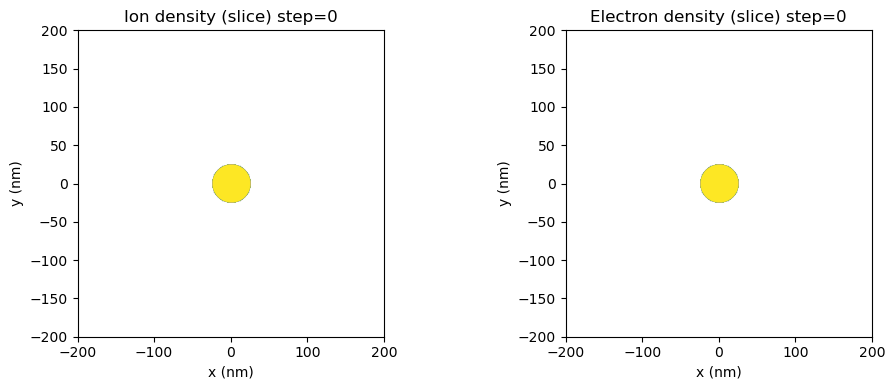

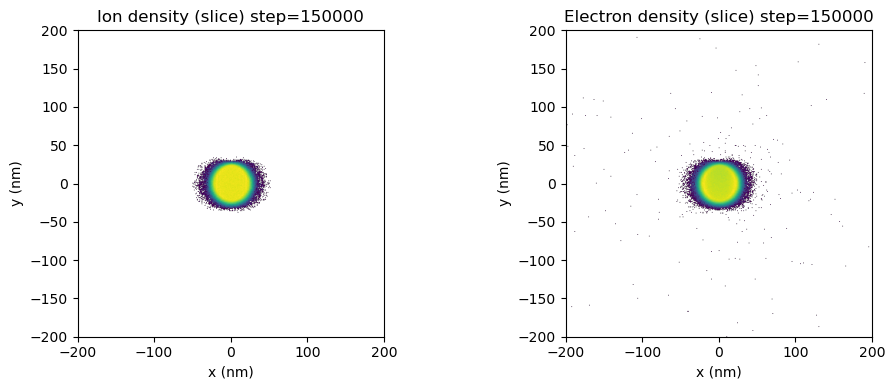

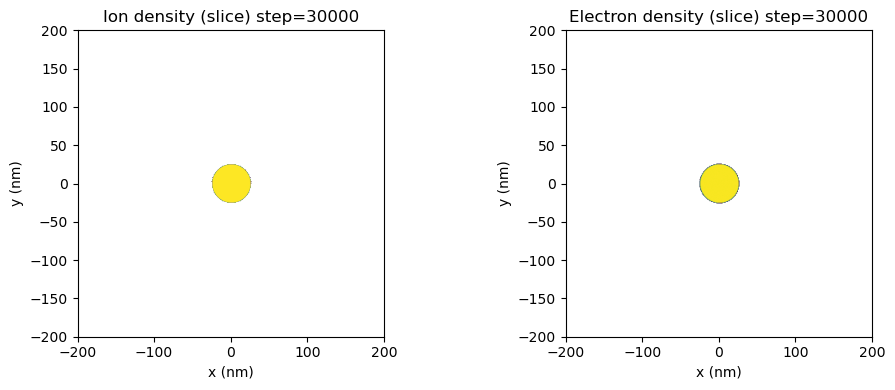

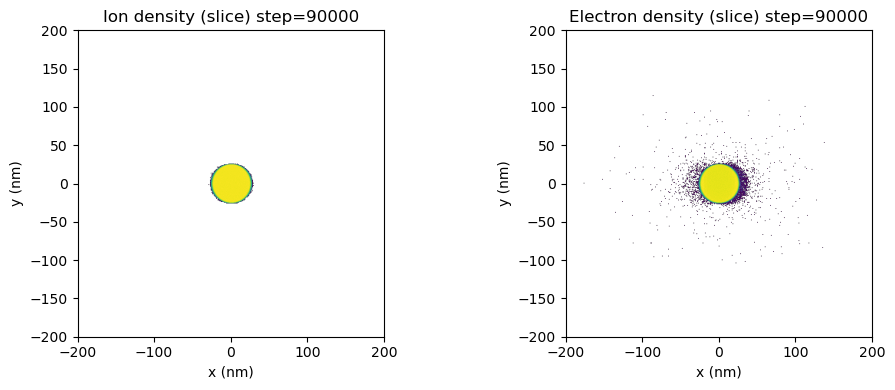

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import adios2, glob
from nanoplasma_analysis_final import extract_step_from_filename

# --- settings ---
NBINS = 400            # increase for more resolution
VIEW_NM = 200          # plot window half-size (nm)
species_e = E_SPECIES  # "He_e"
species_i = ION_SPECIES# "He_i"

# pick which files (timesteps) to plot
files = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))
sel_idx = [0, len(files)//3, 2*len(files)//3, len(files)-1]

def read_xyz_w(fn, step, sp):
    with adios2.Stream(fn, "r") as f:
        for _ in f.steps():
            x = f.read(f"/data/{step}/particles/{sp}/position/x").astype(np.float64)
            y = f.read(f"/data/{step}/particles/{sp}/position/y").astype(np.float64)
            z = f.read(f"/data/{step}/particles/{sp}/position/z").astype(np.float64)
            w = f.read(f"/data/{step}/particles/{sp}/weighting").astype(np.float64)
            # offsets
            xo = f.read(f"/data/{step}/particles/{sp}/positionOffset/x").astype(np.int64)
            yo = f.read(f"/data/{step}/particles/{sp}/positionOffset/y").astype(np.int64)
            zo = f.read(f"/data/{step}/particles/{sp}/positionOffset/z").astype(np.int64)
            return x,y,z,w,xo,yo,zo

def to_SI(x,y,z,xo,yo,zo, dx,dy,dz):
    # x,y,z are fractional [0,1), offsets are cell indices
    X = (xo + x) * dx
    Y = (yo + y) * dy
    Z = (zo + z) * dz
    return X,Y,Z

# get dx,dy,dz from your run meta (nanoplasma_analysis_final style)
run = NanoPlasmaRun(path=SIMOUTPUT, laser_peak_at_target=LASER_PEAK_STEP)
run._load_meta()
dx,dy,dz = float(run.Dx_SI), float(run.Dy_SI), float(run.Dz_SI)

for j in sel_idx:
    fn = files[j]
    step = extract_step_from_filename(fn)

    # ions
    xi, yi, zi, wi, xoi, yoi, zoi = read_xyz_w(fn, step, species_i)
    Xi, Yi, Zi = to_SI(xi, yi, zi, xoi, yoi, zoi, dx,dy,dz)

    # electrons
    xe, ye, ze, we, xoe, yoe, zoe = read_xyz_w(fn, step, species_e)
    Xe, Ye, Ze = to_SI(xe, ye, ze, xoe, yoe, zoe, dx,dy,dz)

    # center using ion COM (XY plane)
    W = np.sum(wi) + 1e-30
    x0 = np.sum(Xi*wi)/W
    y0 = np.sum(Yi*wi)/W
    z0 = np.sum(Zi*wi)/W

    # choose plane: XY slice by selecting particles close to z0
    SLICE_THICK_NM = 2.0  # thickness in nm
    dz_cut = SLICE_THICK_NM * 1e-9

    mask_i = np.abs(Zi - z0) < dz_cut
    mask_e = np.abs(Ze - z0) < dz_cut

    # histogram range around center
    L = VIEW_NM * 1e-9
    xedges = np.linspace(x0 - L, x0 + L, NBINS+1)
    yedges = np.linspace(y0 - L, y0 + L, NBINS+1)

    Hi, _, _ = np.histogram2d(Xi[mask_i], Yi[mask_i], bins=[xedges,yedges], weights=wi[mask_i])
    He, _, _ = np.histogram2d(Xe[mask_e], Ye[mask_e], bins=[xedges,yedges], weights=we[mask_e])

    # plot
    extent_nm = [-VIEW_NM, VIEW_NM, -VIEW_NM, VIEW_NM]

    fig, axs = plt.subplots(1, 2, figsize=(10,4))
    axs[0].imshow(Hi.T, origin="lower", extent=extent_nm, norm=LogNorm(vmin=1, vmax=max(1,np.max(Hi))))
    axs[0].set_title(f"Ion density (slice) step={step}")
    axs[0].set_xlabel("x (nm)"); axs[0].set_ylabel("y (nm)")

    axs[1].imshow(He.T, origin="lower", extent=extent_nm, norm=LogNorm(vmin=1, vmax=max(1,np.max(He))))
    axs[1].set_title(f"Electron density (slice) step={step}")
    axs[1].set_xlabel("x (nm)"); axs[1].set_ylabel("y (nm)")

    plt.tight_layout()
    plt.show()

In [4]:
import adios2, numpy as np
from nanoplasma_analysis_final import extract_step_from_filename
import glob

bp5 = sorted(glob.glob(SIMOUTPUT + "/openPMD/*.bp5"))[0]
step = extract_step_from_filename(bp5)

with adios2.Stream(bp5, "r") as f:
    for _ in f.steps():
        # grid shape from B field
        Nz, Ny, Nx = np.array(
            f.available_variables()[f"/data/{step}/fields/B/x"]["Shape"].split(", "),
            dtype=int
        )

        unitL = f.read_attribute(f"/data/{step}/unit_length")
        dx = f.read_attribute(f"/data/{step}/cell_width")  * unitL
        dy = f.read_attribute(f"/data/{step}/cell_height") * unitL
        dz = f.read_attribute(f"/data/{step}/cell_depth")  * unitL

        print("Nx,Ny,Nz =", Nx, Ny, Nz)
        print("dx,dy,dz (nm) =", dx*1e9, dy*1e9, dz*1e9)
        break

Nx,Ny,Nz = 1024 1600 1024
dx,dy,dz (nm) = 0.5 0.5 0.5
